In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
from pathlib import Path
from os.path import join
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Audio, display

from vap.data.dset_event import VAPClassificationDataset
from vap.eval_events import plot_accuracy_now_vs_fut
from vap.utils.utils import read_json
from vap.utils.plot import plot_melspectrogram, plot_vap_probs, plot_vad
from vap.modules.lightning_module import VAPModule, VAP, everything_deterministic

everything_deterministic()

In [3]:
DIR_PATH = "/home/joao.lima/experiments/VAP/data/eval/results"
metadata = read_json(join(DIR_PATH, 'metadata.json'))

# Should use full paths
metadata['csv'] = join('..', metadata['csv'])
metadata['checkpoint'] = join('..', metadata['checkpoint'])

# Load results
df = pd.read_csv(join(DIR_PATH, 'predictions.csv'))
af = pd.read_csv(join(DIR_PATH, 'accuracy.csv'))
metadata

{'checkpoint': '../runs/checkpoints/epoch=7-step=57040.ckpt',
 'csv': '../data/eval/vad_events.csv',
 'output_dir': 'data/eval/results',
 'plot': False,
 'context': 20,
 'region_sil_pad_time': 0.2,
 'region_duration': 0.2,
 'post_silence': 1.0,
 'min_event_silence': 0,
 'batch_size': 32,
 'num_workers': 8,
 'prefetch_factor': 2,
 'events_total': 94962,
 'events_shift': 0.11429835091931509,
 'events_hold': 0.8857016490806849}

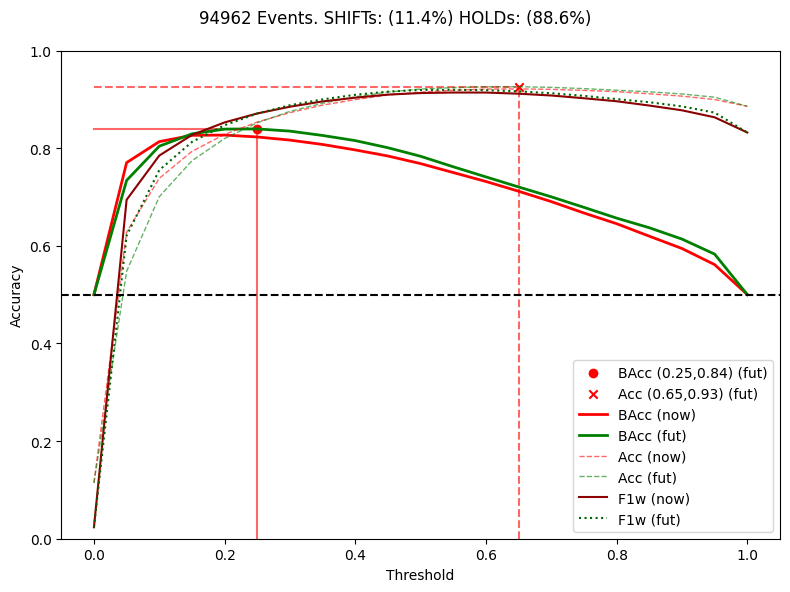

In [4]:
N = {'total': metadata['events_total'], 'shift': metadata['events_shift'], 'hold': 1-metadata['events_shift']}
fig, ax = plot_accuracy_now_vs_fut(af, N=N)

# Model Output

Look at the actual output from the model over random samples from the data.

In [39]:
def plot_output(d, out, height_ratios=[2, 2, 2, 2, 1.5, 1.5, 1.5, 1.5], frame_hz:int=50, sample_rate:int=16000):
    # Create the figure and the GridSpec instance with the given height ratios
    fig, ax = plt.subplots(
        nrows=8,
        sharex=True,
        figsize=(15, 6),
        gridspec_kw={"height_ratios": height_ratios, "hspace": 0.01},
    )
    
    # Pad waveform to the full length so the empty right region gets the spectrogram's zero color
    w_pad = torch.zeros_like(d['waveform_extended'])
    w_pad[:, :d['waveform'].shape[-1]] = d['waveform']
    plot_melspectrogram(w_pad, ax=ax[:2])
    
    plot_melspectrogram(d['waveform_extended'], ax=ax[2:4])
    
    # Add Roman numeral labels to the upper right corner of the melspectrograms
    roman_labels = ["I", "II", "III", "IV"]
    for i in range(4):
        ax[i].text(0.99, 0.9, roman_labels[i], transform=ax[i].transAxes,
                   color="white", fontsize=14, fontweight="bold",
                   ha="right", va="top")

    x2 = torch.arange(out["vad"].shape[1]) / frame_hz
    plot_vad(x2, out["vad"][0, :, 0], ax[0], ypad=3, color="w", label="VAD pred")
    plot_vad(x2, out["vad"][0, :, 1], ax[1], ypad=3, color="w", label="VAD pred")
    for i in range(4):
        label = f"P_bin_{i+1}"
        plot_vap_probs(out["p"][i, 0], ax=ax[4 + i], prob_label=label)
    ax[0].set_xticks([])
    ax[1].set_xticks([])
    ax[0].legend(loc="upper left")
    ax[1].legend(loc="upper left")
    
    # Extend x-axis to waveform_extended length
    total_duration = d['waveform_extended'].shape[-1] / sample_rate
    ax[-1].set_xticks(list(range(0, 1 + int(round(total_duration)))))
    ax[-1].set_xlim(0, total_duration)
    ax[-1].set_xlabel("Time (s)")
    return fig, ax

def plot_event_region(start, end, d, ax):
    if d['label'] == 'shift':
        if d['speaker'] == 0:
            color = 'orange'
        else:
            color = 'blue'
    else:
        if d['speaker'] == 0:
            color = 'blue'
        else:
            color = 'orange'
    for a in ax:
        a.axvline(start, color=color)
        a.axvline(end, color=color)

In [16]:
model = VAPModule.load_model(metadata['checkpoint'])
dset = VAPClassificationDataset(
        df_path=metadata['csv'],
        context=metadata['context'],
        post_silence=metadata['post_silence'],
        min_event_silence=0,
    )
region_start_time = metadata['context'] + metadata['region_sil_pad_time']
region_end_time = region_start_time + metadata['region_duration']

/home/joao.lima/miniconda3/envs/vap/lib/python3.10/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
/home/joao.lima/miniconda3/envs/vap/

/home/joao.lima/miniconda3/envs/vap/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.


Session: V03_S1587_I00000146.wav
IPU End:  194.42
Label:  shift
P-now:  0.565
P-fut:  0.492
P-1:  0.581
P-2:  0.56
P-3:  0.501
P-4:  0.484


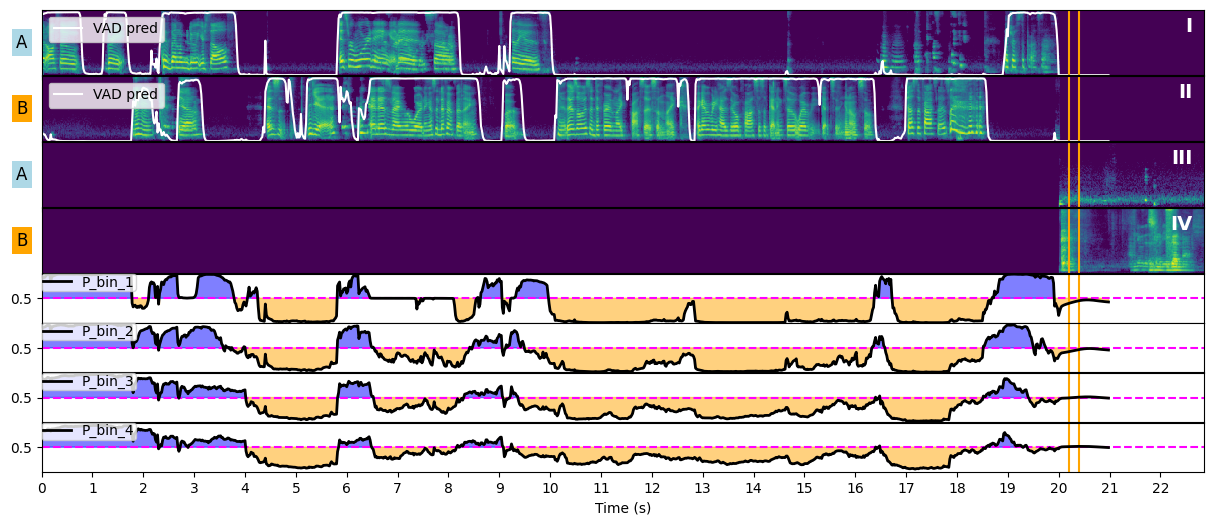

In [40]:
desired_event = 'shift'

def rand_sample_target_event(dset, desired_event):
    while True:
        idx = torch.randint(0, len(dset), (1,)).item()
        d = dset[idx]
        if d['label'] == desired_event:
            return d

d = rand_sample_target_event(dset, desired_event)
waveform = d['waveform']
waveform_extended = d['waveform_extended']

with torch.inference_mode():
    out = model.probs(waveform.unsqueeze(0).to(model.device))
    preds = model.get_shift_probability(
            out, region_start_time, region_end_time, d["speaker"]
        )

fig, ax = plot_output(d, out)
plot_event_region(region_start_time, region_end_time, d, ax)
print('Session:', d['session'])
print('IPU End: ', d['ipu_end'])
print('Label: ', d['label'])
print('P-now: ', round(preds['p_now'][0], 3))
print('P-fut: ', round(preds['p_fut'][0], 3))
print('P-1: ', round(preds['p1'][0], 3))
print('P-2: ', round(preds['p2'][0], 3))
print('P-3: ', round(preds['p3'][0], 3))
print('P-4: ', round(preds['p4'][0], 3))
display(Audio(waveform.numpy(), rate=16000))